### Cell 0 – Install packages and set up warnings

In [1]:
!pip install scikit-fuzzy umap-learn --quiet
import warnings
warnings.filterwarnings("ignore")


### Cell 1 – Import libraries


In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
import umap
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import seaborn as sns


### Cell 2 – Load dataset from local CSV (VS Code)

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)
df.head()


(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Cell-3- Basic EDA

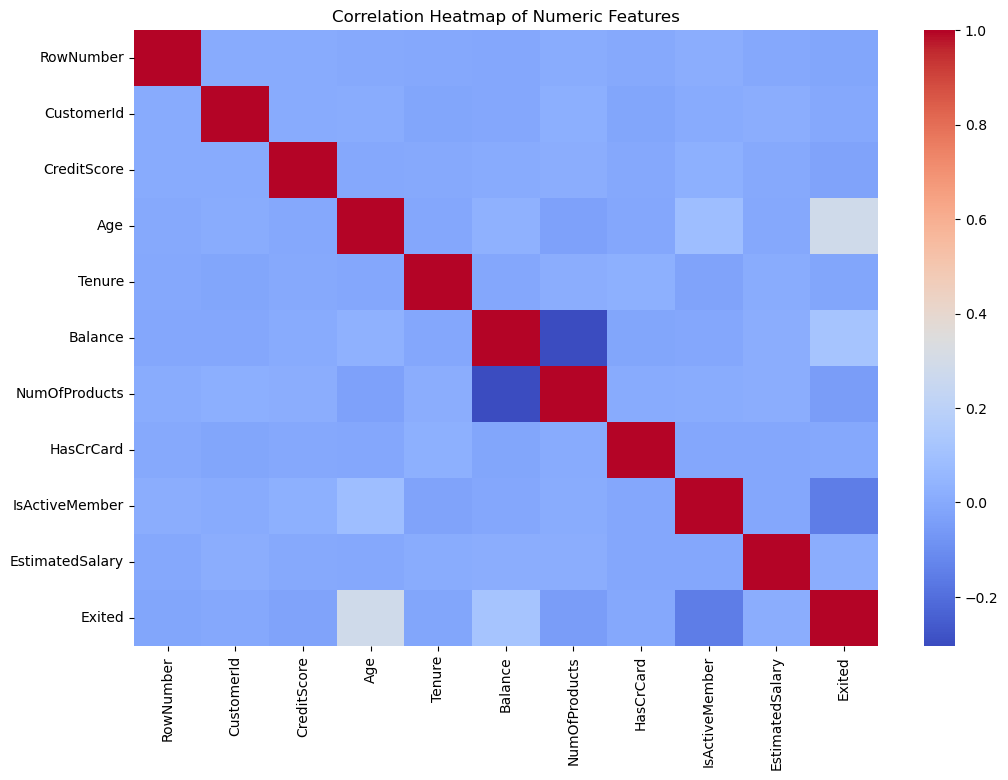

In [5]:
# Heatmap for numeric columns only
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


In [6]:
#Drop ID columns
to_drop = ["RowNumber", "CustomerId", "Surname"]
df = df.drop([c for c in to_drop if c in df.columns], axis=1)

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Impute ONLY numeric columns with median
imputer = SimpleImputer(strategy="median")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

df_clean = df.copy()
df_clean.head()

Numeric columns: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
Categorical columns: Index(['Geography', 'Gender'], dtype='object')


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619.0,France,Female,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,699.0,France,Female,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0


In [7]:
#Encoding
df_enc = pd.get_dummies(df_clean, columns=["Geography", "Gender"], drop_first=True)
print(df_enc.shape)
df_enc.head()

(10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0,False,False,False
1,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0,False,True,False
2,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0,False,False,False
3,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0,False,False,False
4,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0,False,True,False


In [8]:
#Strong columns selection
strong_cols = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary",
    "Geography_Germany", "Geography_Spain", "Gender_Male"
]

df_strong = df_enc[strong_cols]
print(df_strong.shape)


(10000, 11)


In [9]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_strong)
X_scaled.shape


(10000, 11)

In [10]:
#Outlier removal
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels_lof = lof.fit_predict(X_scaled)
X_lof = X_scaled[labels_lof == 1]

iso = IsolationForest(contamination=0.05, random_state=42)
labels_iso = iso.fit_predict(X_lof)
X_out = X_lof[labels_iso == 1]

print("After outlier removal:", X_out.shape)


After outlier removal: (9025, 11)


In [11]:
# PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_out)

print("PCA shape:", X_pca.shape)



PCA shape: (9025, 10)


In [12]:
# UMAP
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    metric='euclidean',
    random_state=42
)

X_umap = umap_model.fit_transform(X_pca)
print("UMAP shape:", X_umap.shape)


UMAP shape: (9025, 2)


#### Elbow

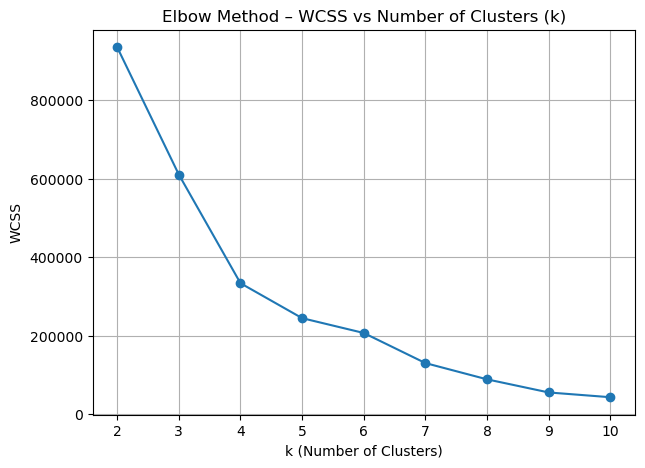

In [13]:

# Elbow Method (to suggest number of clusters using WCSS)

from sklearn.cluster import KMeans

wcss = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_umap)       # using the UMAP-reduced data
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, wcss, marker="o")
plt.title("Elbow Method – WCSS vs Number of Clusters (k)")
plt.xlabel("k (Number of Clusters)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


In [14]:
# FCM function
def run_fcm(data, c):
    data_T = data.T

    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data_T, c=c, m=1.7, error=1e-5, maxiter=400, seed=42
    )

    labels = np.argmax(u, axis=0)
    sil = silhouette_score(data, labels)

    return sil, fpc, labels, cntr, u


In [15]:
#Remove ambiguous rows
_, _, _, _, u_tmp = run_fcm(X_umap, 4)

u_max = u_tmp.max(axis=0)
mask = (u_max < 0.45) | (u_max > 0.55)

X_final = X_umap[mask]
print("After removing ambiguous rows:", X_final.shape)


After removing ambiguous rows: (8827, 2)


c=2 → Silhouette=0.4040, FPC=0.7793
c=3 → Silhouette=0.4650, FPC=0.7659
c=4 → Silhouette=0.5088, FPC=0.7578
c=5 → Silhouette=0.5854, FPC=0.7937
c=6 → Silhouette=0.5769, FPC=0.7912
c=7 → Silhouette=0.6378, FPC=0.8480
c=8 → Silhouette=0.6895, FPC=0.8701
c=9 → Silhouette=0.6831, FPC=0.8652
c=10 → Silhouette=0.7125, FPC=0.8851


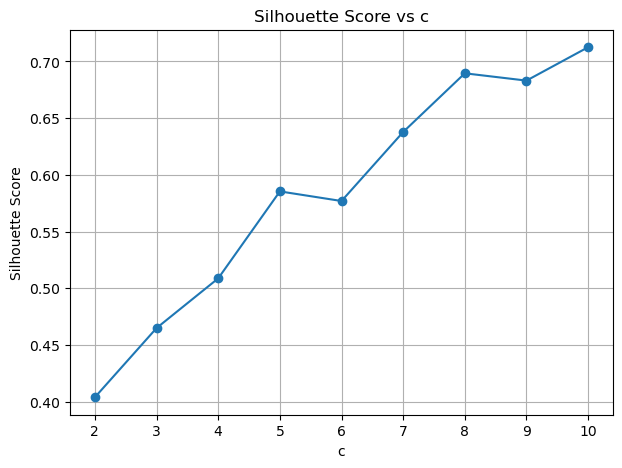


Best c = 10


In [16]:
#Search best c
C_range = range(2, 11)
sil_scores = []
fpc_scores = []

for c in C_range:
    sil, fpc, labels, cntr, u = run_fcm(X_final, c)
    sil_scores.append(sil)
    fpc_scores.append(fpc)
    print(f"c={c} → Silhouette={sil:.4f}, FPC={fpc:.4f}")

plt.figure(figsize=(7,5))
plt.plot(C_range, sil_scores, marker="o")
plt.xlabel("c")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs c")
plt.grid(True)
plt.show()

best_c = C_range[np.argmax(sil_scores)]
print("\nBest c =", best_c)

In [17]:
#Final Model
sil, fpc, labels_final, cntr_final, u_final = run_fcm(X_final, best_c)

print("Final FCM Results")
print("----------------")
print("Best c =", best_c)
print("Silhouette Score =", sil)
print("FPC =", fpc)

Final FCM Results
----------------
Best c = 10
Silhouette Score = 0.71249336
FPC = 0.8850809883920233


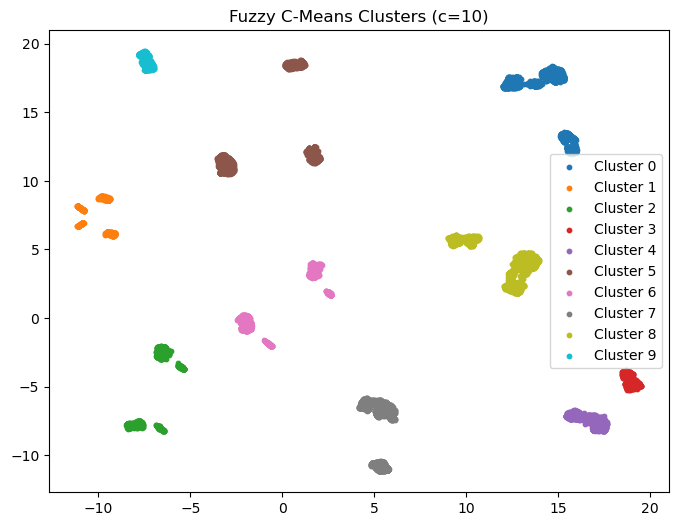

In [18]:
#Plot final clusters
plt.figure(figsize=(8,6))
for c in range(best_c):
    plt.scatter(
        X_final[labels_final == c, 0],
        X_final[labels_final == c, 1],
        s=10,
        label=f"Cluster {c}"
    )

plt.title(f"Fuzzy C-Means Clusters (c={best_c})")
plt.legend()
plt.show()
